
1. **Load raw RSSI and IMU data**  
2. **Compute path‐loss calibration parameters** at a known reference distance  
3. **Convert measured RSSI values into distance estimates** using the log-distance path‐loss model  
4. **Detect heading-change events** from IMU data  
5. **Overlay distance estimates with event markers** in a single plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load raw RSSI and IMU logs
df   = pd.read_csv('rssi.csv')   # contains columns like rssi_1, rssi_2, …
df_1 = pd.read_csv('imu.csv')    # contains IMU readings & a `direction_change` flag
df_2 = pd.read_csv('rssi.csv')   # duplicate reference for calibration code below

In [3]:
def calculate_path_loss_components(df_ref, rssi_column, fixed_distance=1.0, path_loss_exponent=2.0):
    """
    Calculate path loss components when all measurements are at a fixed distance.
    
    Parameters:
    - df_ref: pandas DataFrame with reference measurements
    - rssi_column: name of the column with RSSI values (string)
    - fixed_distance: the known distance for all measurements (default 1.0m)
    - path_loss_exponent: assumed path loss exponent (default 2.0 for free space)
    
    Returns:
    - dict containing:
        - 'rssi_at_ref_distance': average RSSI value at the fixed distance
        - 'path_loss_exponent': the provided/assumed path loss exponent
        - 'sample_count': number of valid RSSI measurements
        - 'rssi_std': standard deviation of RSSI measurements
    """
    import numpy as np
    
    # Remove any invalid measurements (NaN values)
    valid_mask = df_ref[rssi_column].notna()
    rssi_values = df_ref[rssi_column][valid_mask].values
    
    # Calculate statistics
    rssi_mean = np.mean(rssi_values)
    rssi_std = np.std(rssi_values)
    sample_count = len(rssi_values)
    
    return {
        'rssi_at_ref_distance': rssi_mean,
        'path_loss_exponent': path_loss_exponent,
        'sample_count': sample_count,
        'rssi_std': rssi_std,
        'fixed_distance': fixed_distance
    }

In [5]:
 
components = calculate_path_loss_components(df, 'rssi_2', fixed_distance=1.0)
print(f"RSSI at 1m: {components['rssi_at_ref_distance']:.2f} dBm")
print(f"Path Loss Exponent: {components['path_loss_exponent']:.2f}")
print(f"Sample Count: {components['sample_count']}")
print(f"RSSI Std Dev: {components['rssi_std']:.2f} dBm")

RSSI at 1m: -79.03 dBm
Path Loss Exponent: 2.00
Sample Count: 4550
RSSI Std Dev: 8.29 dBm


In [ ]:
def convert_rssi_to_distance(df, rssi_column, rssi_at_1m, path_loss_exponent=2.0, new_column_name=None):
    """
    Convert RSSI values to estimated distances using the log-distance path loss model.

    Parameters:
    - df: pandas DataFrame
    - rssi_column: name of the column with RSSI values (string)
    - rssi_at_1m: reference RSSI value at 1 meter (float)
    - path_loss_exponent: environment factor, default is 2.0 (free space)
    - new_column_name: optional name for the output column (string). If None, will default to 'distance_from_' + rssi_column

    Returns:
    - df with a new column for estimated distances
    """
    import numpy as np
    
    if new_column_name is None:
        new_column_name = f'distance_from_{rssi_column}'

    df[new_column_name] = 10 ** ((rssi_at_1m - df[rssi_column]) / (10 * path_loss_exponent))
    return df

In [8]:
components_1 = calculate_path_loss_components(df, 'rssi_1', fixed_distance=1.0)
components_2 = calculate_path_loss_components(df, 'rssi_2', fixed_distance=1.0)

We want to mark on the distance‐versus‐time plot the instants where the device changed heading.

 

- Two distance traces (blue/orange) give us an idea of how the antenna‐calculated range varies over time.

- Vertical red lines clealry shows how when the device turned, so below in the plot we can  can correlate turning events with jumps  in the estimated range of the path loss model.

Distance conversion completed!
New columns added: calibrated_distance_1, calibrated_distance_2


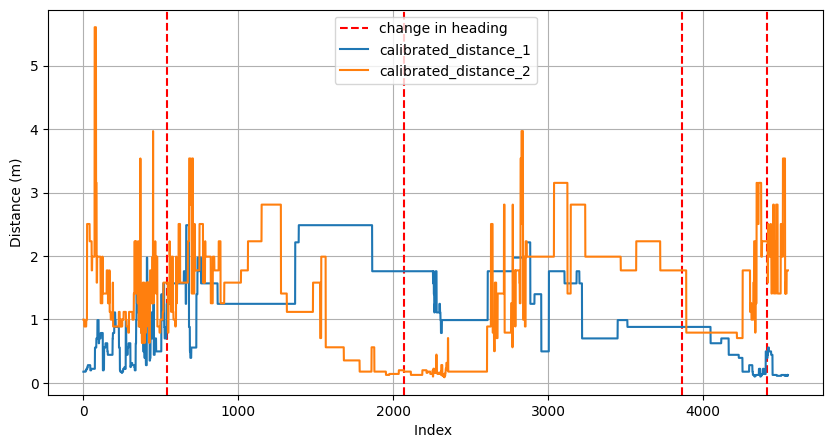

In [9]:
# we ar eapplyying the log distance  Path loss model
df = convert_rssi_to_distance(
    df, 
    'rssi_1', 
    rssi_at_1m=components_1['rssi_at_ref_distance'],
    path_loss_exponent=components_1['path_loss_exponent'],
    new_column_name='calibrated_distance_1'
)




df = convert_rssi_to_distance(
    df, 
    'rssi_2', 
    rssi_at_1m=components_2['rssi_at_ref_distance'],
    path_loss_exponent=components_2['path_loss_exponent'],
    new_column_name='calibrated_distance_2'
)

print("Distance conversion completed!")
print(f"New columns added: calibrated_distance_1, calibrated_distance_2")


# Define changes using df_1   -------------------# In the IMU DataFrame, find every row where `direction_change == 1`
changes = df_1.index[df_1['direction_change'] == 1]

fig, ax = plt.subplots(figsize=(10, 5))

for i, change in enumerate(changes):
    if i == 0:
        ax.axvline(x=change, linestyle='--', color='red', label='change in heading')
    else:
        ax.axvline(x=change, linestyle='--', color='red')

ax.plot(df['calibrated_distance_1'], label='calibrated_distance_1')
ax.plot(df['calibrated_distance_2'], label='calibrated_distance_2')  # fixed label here too
ax.legend()
ax.set_xlabel('Index ')
ax.set_ylabel('Distance (m)')
ax.grid()
plt.show()

Calibration at 1 m ensures that the distance estimates are referenced to a real value.

Log-distance model is a common, lightweight way to go from RSSI to distance in radio‐propagation experiments.

Overlaying IMU events lets you visually inspect how motion (especially turns) affects signal‐based ranging.

Combined plot is an effective diagnostic for verifying whether RSSI-based distance estimates make sense when the device orientation changes.

References 

+ https://github.com/ANRGUSC/WirelessRangeEstimation/blob/master/estimate_distance.py (Distance estimations )
+ https://www.bleuio.com/blog/measuring-distance-with-bluetooth-in-indoor-environment-using-python/ (Formula rssi to distance) 